# Import des librairies

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import islice
from tqdm.auto import tqdm
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
from IPython.display import clear_output, display
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Demo on MNIST

## Loading the datasets

Chargement Fashion-MNIST: 100%|██████████| 10/10 [00:00<00:00, 131.27it/s]


MNIST (train, test) : 60000, 10000
Fashion-MNIST (train, test) : 60000, 10000
Exemples d'images MNIST et Fashion-MNIST :


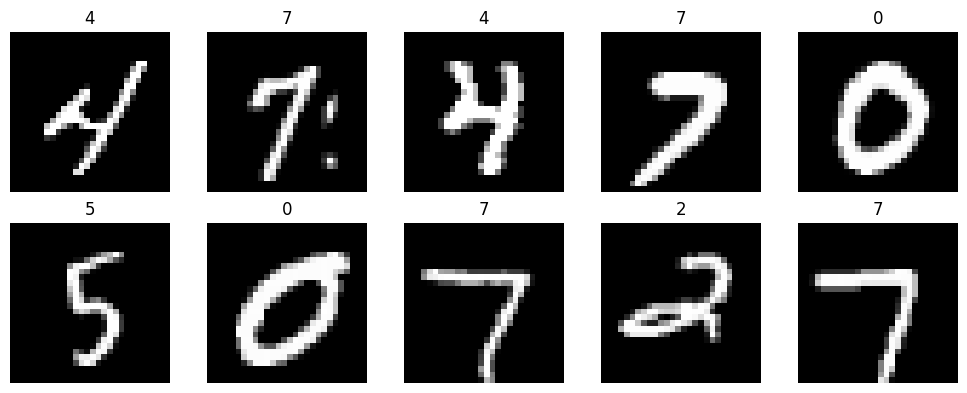

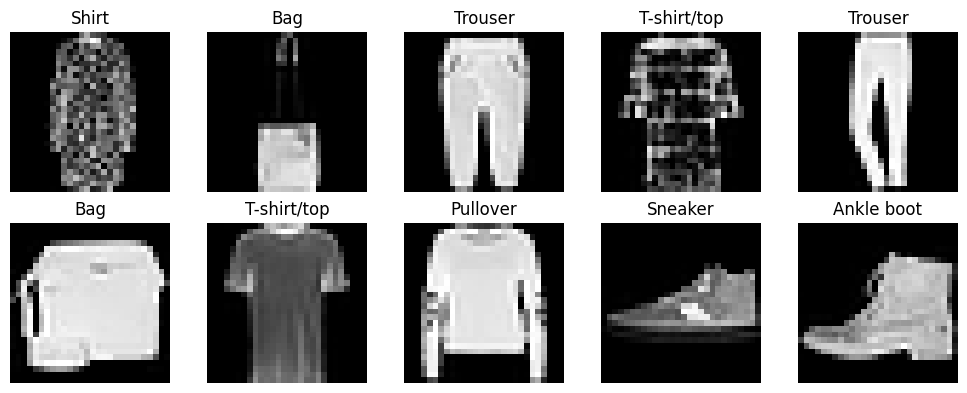

In [ ]:
data_root = "./dataset"
batch_size = 128

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

mnist_train = datasets.MNIST(root=data_root, train=True, download=True, transform=transform)
mnist_test = datasets.MNIST(root=data_root, train=False, download=True, transform=transform)

fashion_train = datasets.FashionMNIST(root=data_root, train=True, download=True, transform=transform)
fashion_test = datasets.FashionMNIST(root=data_root, train=False, download=True, transform=transform)

mnist_train_loader = DataLoader(mnist_train, batch_size=batch_size, shuffle=True)
mnist_test_loader = DataLoader(mnist_test, batch_size=batch_size, shuffle=False)

fashion_train_loader = DataLoader(fashion_train, batch_size=batch_size, shuffle=True)
fashion_test_loader = DataLoader(fashion_test, batch_size=batch_size, shuffle=False)

# Loading bar
for _ in tqdm(islice(mnist_train_loader, 10), total=10, desc="Loading MNIST"):
    pass
for _ in tqdm(islice(fashion_train_loader, 10), total=10, desc="Loading Fashion-MNIST"):
    pass

print(f"MNIST (train, test) : {len(mnist_train)}, {len(mnist_test)}\nFashion-MNIST (train, test) : {len(fashion_train)}, {len(fashion_test)}")

print("Examples of MNIST and Fashion-MNIST images:")

# Display 10 random MNIST images with their labels
if "mnist_train" not in globals():
    data_root = "./dataset"
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,)),
    ])
    mnist_train = datasets.MNIST(root=data_root, train=True, download=True, transform=transform)

idx = np.random.choice(len(mnist_train), size=10, replace=False)
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
axes = axes.flatten()

for ax, i in zip(axes, idx):
    img, label = mnist_train[i]
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(str(label))
    ax.axis("off")

plt.tight_layout()
plt.show()

# Display 10 random Fashion-MNIST images with their labels
if "fashion_train" not in globals():
    data_root = "./dataset"
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,)),
    ])
    fashion_train = datasets.FashionMNIST(root=data_root, train=True, download=True, transform=transform)

fashion_classes = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
 ]

idx = np.random.choice(len(fashion_train), size=10, replace=False)
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
axes = axes.flatten()

for ax, i in zip(axes, idx):
    img, label = fashion_train[i]
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(fashion_classes[label])
    ax.axis("off")

plt.tight_layout()
plt.show()

## Training our models

### Supervised Learning : Multi-Layer Perceptron

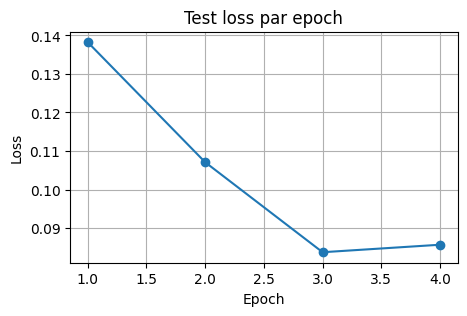

MLP_MNIST(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Linear(in_features=256, out_features=128, bias=True)
    (6): ReLU()
    (7): Linear(in_features=128, out_features=64, bias=True)
    (8): ReLU()
    (9): Linear(in_features=64, out_features=32, bias=True)
    (10): ReLU()
    (11): Linear(in_features=32, out_features=10, bias=True)
  )
)


In [26]:
# Entraînement d'un MLP sur GPU (si dispo)
from IPython.display import clear_output, display

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

class MLP_MNIST(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 512), nn.ReLU(),
            nn.Linear(512, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 10)
        )

    def forward(self, x):
        return self.net(x)

mlp_mnist = MLP_MNIST().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(mlp_mnist.parameters(), lr=1e-3)

epochs = 4
test_losses = []

fig, ax = plt.subplots(figsize=(5, 3))
for epoch in range(1, epochs + 1):
    mlp_mnist.train()
    running_loss = 0.0
    for x, y in tqdm(mnist_train_loader, desc=f"Epoch {epoch}"):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = mlp_mnist(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * x.size(0)
    train_loss = running_loss / len(mnist_train_loader.dataset)

    mlp_mnist.eval()
    correct = 0
    total = 0
    test_loss = 0.0
    with torch.no_grad():
        for x, y in mnist_test_loader:
            x, y = x.to(device), y.to(device)
            logits = mlp_mnist(x)
            loss = criterion(logits, y)
            test_loss += loss.item() * x.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    test_loss = test_loss / len(mnist_test_loader.dataset)
    test_losses.append(test_loss)
    acc = correct / total
    print(f"Epoch {epoch} - loss: {train_loss:.4f} - val_loss: {test_loss:.4f} - acc: {acc:.4f}")

    # Actualisation du même graphe (taille fixe)
    clear_output(wait=True)
    ax.cla()
    ax.plot(range(1, len(test_losses) + 1), test_losses, marker="o")
    ax.set_title("Test loss par epoch")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(True)
    display(fig)

plt.close(fig)
print(mlp_mnist)

### Supervised Learning : Convolutional Neural Network

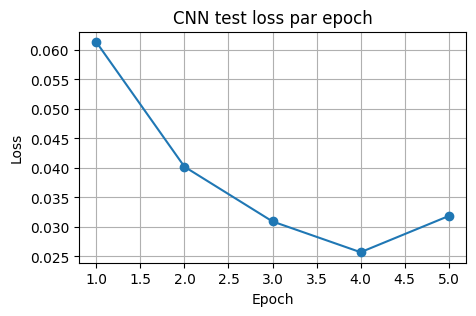

CNN_MNIST(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=6272, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [29]:
# Entraînement d'un CNN sur GPU (si dispo)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

class CNN_MNIST(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

cnn_mnist = CNN_MNIST().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_mnist.parameters(), lr=1e-3)

epochs = 5
test_losses = []

fig, ax = plt.subplots(figsize=(5, 3))
for epoch in range(1, epochs + 1):
    cnn_mnist.train()
    running_loss = 0.0
    for x, y in tqdm(mnist_train_loader, desc=f"CNN Epoch {epoch}"):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = cnn_mnist(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * x.size(0)
    train_loss = running_loss / len(mnist_train_loader.dataset)

    cnn_mnist.eval()
    correct = 0
    total = 0
    test_loss = 0.0
    with torch.no_grad():
        for x, y in mnist_test_loader:
            x, y = x.to(device), y.to(device)
            logits = cnn_mnist(x)
            loss = criterion(logits, y)
            test_loss += loss.item() * x.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    test_loss = test_loss / len(mnist_test_loader.dataset)
    test_losses.append(test_loss)
    acc = correct / total
    print(f"CNN Epoch {epoch} - loss: {train_loss:.4f} - val_loss: {test_loss:.4f} - acc: {acc:.4f}")

    # Actualisation du même graphe (taille fixe)
    clear_output(wait=True)
    ax.cla()
    ax.plot(range(1, len(test_losses) + 1), test_losses, marker="o")
    ax.set_title("CNN test loss par epoch")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(True)
    display(fig)

plt.close(fig)
print(cnn_mnist)

### Unsupervised Learning : MLP Auto-Encoder

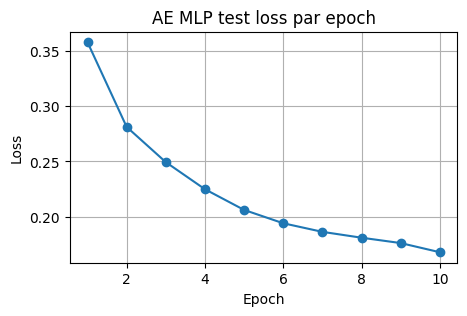

AE_MLP_MNIST(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=256, bias=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=512, bias=True)
    (7): ReLU()
    (8): Linear(in_features=512, out_features=784, bias=True)
  )
)


In [34]:
# Entraînement d'un Auto-Encodeur MLP (miroir) sur GPU (si dispo)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

class AE_MLP_MNIST(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 512), nn.ReLU(),
            nn.Linear(512, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(32, 64), nn.ReLU(),
            nn.Linear(64, 128), nn.ReLU(),
            nn.Linear(128, 256), nn.ReLU(),
            nn.Linear(256, 512), nn.ReLU(),
            nn.Linear(512, 28 * 28)
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

ae_mlp_mnist = AE_MLP_MNIST().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(ae_mlp_mnist.parameters(), lr=1e-3)

epochs = 10
test_losses = []

fig, ax = plt.subplots(figsize=(5, 3))
for epoch in range(1, epochs + 1):
    ae_mlp_mnist.train()
    running_loss = 0.0
    for x, _ in tqdm(mnist_train_loader, desc=f"AE Epoch {epoch}"):
        x = x.to(device)
        x_flat = x.view(x.size(0), -1)
        optimizer.zero_grad()
        recon = ae_mlp_mnist(x_flat)
        loss = criterion(recon, x_flat)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * x.size(0)
    train_loss = running_loss / len(mnist_train_loader.dataset)

    ae_mlp_mnist.eval()
    test_loss = 0.0
    with torch.no_grad():
        for x, _ in mnist_test_loader:
            x = x.to(device)
            x_flat = x.view(x.size(0), -1)
            recon = ae_mlp_mnist(x_flat)
            loss = criterion(recon, x_flat)
            test_loss += loss.item() * x.size(0)
    test_loss = test_loss / len(mnist_test_loader.dataset)
    test_losses.append(test_loss)
    print(f"AE Epoch {epoch} - loss: {train_loss:.4f} - val_loss: {test_loss:.4f}")

    # Actualisation du même graphe (taille fixe)
    clear_output(wait=True)
    ax.cla()
    ax.plot(range(1, len(test_losses) + 1), test_losses, marker="o")
    ax.set_title("AE MLP test loss par epoch")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(True)
    display(fig)

plt.close(fig)
print(ae_mlp_mnist)

### Unsupervised Learning : CNN Auto-Encoder

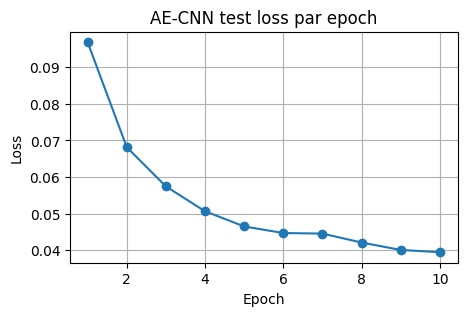

AE_CNN_MNIST(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (bottleneck): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=6272, out_features=32, bias=True)
  )
  (unbottleneck): Sequential(
    (0): Linear(in_features=32, out_features=6272, bias=True)
    (1): ReLU()
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(2, 2), stride=(2, 2))
    (1): ReLU()
    (2): ConvTranspose2d(64, 32, kernel_size=(2, 2), stride=(2, 2))
    (3): ReLU()
    (4): Conv2d(32, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))


In [40]:
# Entraînement d'un Auto-Encodeur CNN (miroir) sur GPU (si dispo)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

class AE_CNN_MNIST(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.bottleneck = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 32)
        )
        self.unbottleneck = nn.Sequential(
            nn.Linear(32, 128 * 7 * 7),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2), nn.ReLU(),
            nn.Conv2d(32, 1, kernel_size=3, padding=1)
        )

    def forward(self, x):
        x = self.encoder(x)
        z = self.bottleneck(x)
        x = self.unbottleneck(z).view(-1, 128, 7, 7)
        x = self.decoder(x)
        return x

ae_cnn_mnist = AE_CNN_MNIST().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(ae_cnn_mnist.parameters(), lr=1e-3)

epochs = 10
test_losses = []

fig, ax = plt.subplots(figsize=(5, 3))
for epoch in range(1, epochs + 1):
    ae_cnn_mnist.train()
    running_loss = 0.0
    for x, _ in tqdm(mnist_train_loader, desc=f"AE-CNN Epoch {epoch}"):
        x = x.to(device)
        optimizer.zero_grad()
        recon = ae_cnn_mnist(x)
        loss = criterion(recon, x)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * x.size(0)
    train_loss = running_loss / len(mnist_train_loader.dataset)

    ae_cnn_mnist.eval()
    test_loss = 0.0
    with torch.no_grad():
        for x, _ in mnist_test_loader:
            x = x.to(device)
            recon = ae_cnn_mnist(x)
            loss = criterion(recon, x)
            test_loss += loss.item() * x.size(0)
    test_loss = test_loss / len(mnist_test_loader.dataset)
    test_losses.append(test_loss)
    print(f"AE-CNN Epoch {epoch} - loss: {train_loss:.4f} - val_loss: {test_loss:.4f}")

    # Actualisation du même graphe (taille fixe)
    clear_output(wait=True)
    ax.cla()
    ax.plot(range(1, len(test_losses) + 1), test_losses, marker="o")
    ax.set_title("AE-CNN test loss par epoch")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(True)
    display(fig)

plt.close(fig)
print(ae_cnn_mnist)

### Model performance comparaison

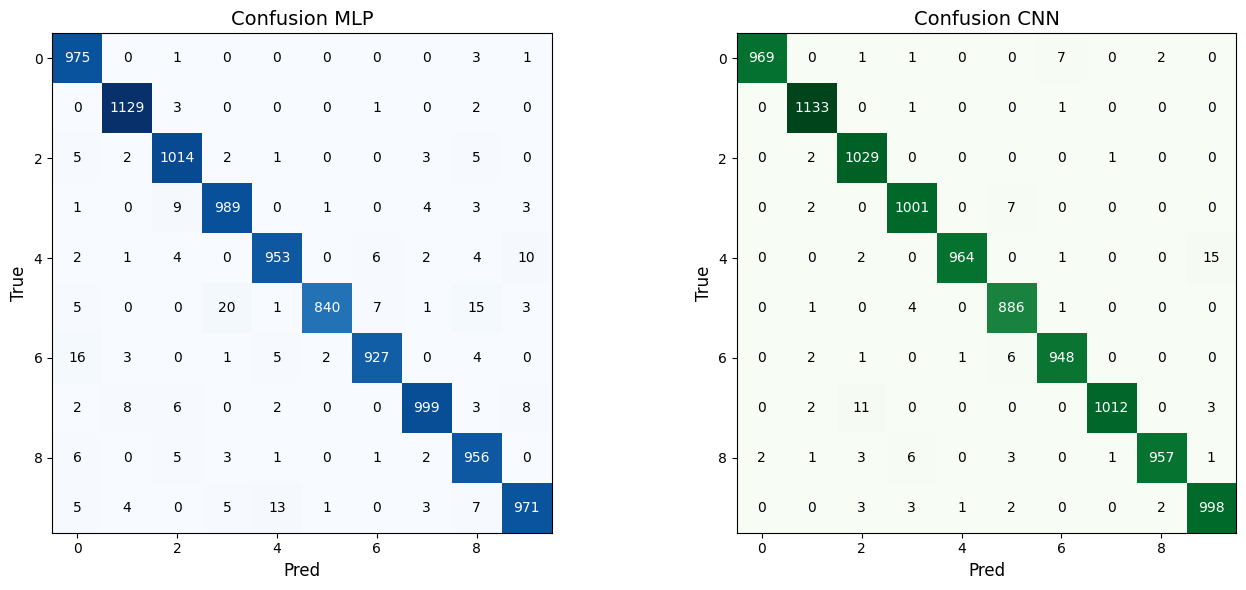

,model,accuracy,precision_macro,recall_macro,f1_macro
0,MLP,0.9753,0.975572,0.974684,0.974977
1,CNN,0.9897,0.989719,0.989578,0.989615


In [41]:
# Comparaison MLP vs CNN sur le test set
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mlp_mnist.eval()
cnn_mnist.eval()

y_true = []
y_pred_mlp = []
y_pred_cnn = []

with torch.no_grad():
    for x, y in mnist_test_loader:
        x = x.to(device)
        logits_mlp = mlp_mnist(x)
        logits_cnn = cnn_mnist(x)
        y_true.extend(y.numpy().tolist())
        y_pred_mlp.extend(logits_mlp.argmax(dim=1).cpu().numpy().tolist())
        y_pred_cnn.extend(logits_cnn.argmax(dim=1).cpu().numpy().tolist())

cm_mlp = confusion_matrix(y_true, y_pred_mlp)
cm_cnn = confusion_matrix(y_true, y_pred_cnn)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(cm_mlp, cmap="Blues")
axes[0].set_title("Confusion MLP", fontsize=14)
axes[0].set_xlabel("Pred", fontsize=12)
axes[0].set_ylabel("True", fontsize=12)
axes[1].imshow(cm_cnn, cmap="Greens")
axes[1].set_title("Confusion CNN", fontsize=14)
axes[1].set_xlabel("Pred", fontsize=12)
axes[1].set_ylabel("True", fontsize=12)

# Afficher les valeurs dans chaque case
for i in range(cm_mlp.shape[0]):
    for j in range(cm_mlp.shape[1]):
        axes[0].text(j, i, cm_mlp[i, j], ha="center", va="center", fontsize=10,
                     color="white" if cm_mlp[i, j] > cm_mlp.max() / 2 else "black")
for i in range(cm_cnn.shape[0]):
    for j in range(cm_cnn.shape[1]):
        axes[1].text(j, i, cm_cnn[i, j], ha="center", va="center", fontsize=10,
                     color="white" if cm_cnn[i, j] > cm_cnn.max() / 2 else "black")

plt.tight_layout()
plt.show()

metrics = pd.DataFrame([
    {
        "model": "MLP",
        "accuracy": accuracy_score(y_true, y_pred_mlp),
        "precision_macro": precision_score(y_true, y_pred_mlp, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred_mlp, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred_mlp, average="macro", zero_division=0),
    },
    {
        "model": "CNN",
        "accuracy": accuracy_score(y_true, y_pred_cnn),
        "precision_macro": precision_score(y_true, y_pred_cnn, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred_cnn, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred_cnn, average="macro", zero_division=0),
    }
])

metrics

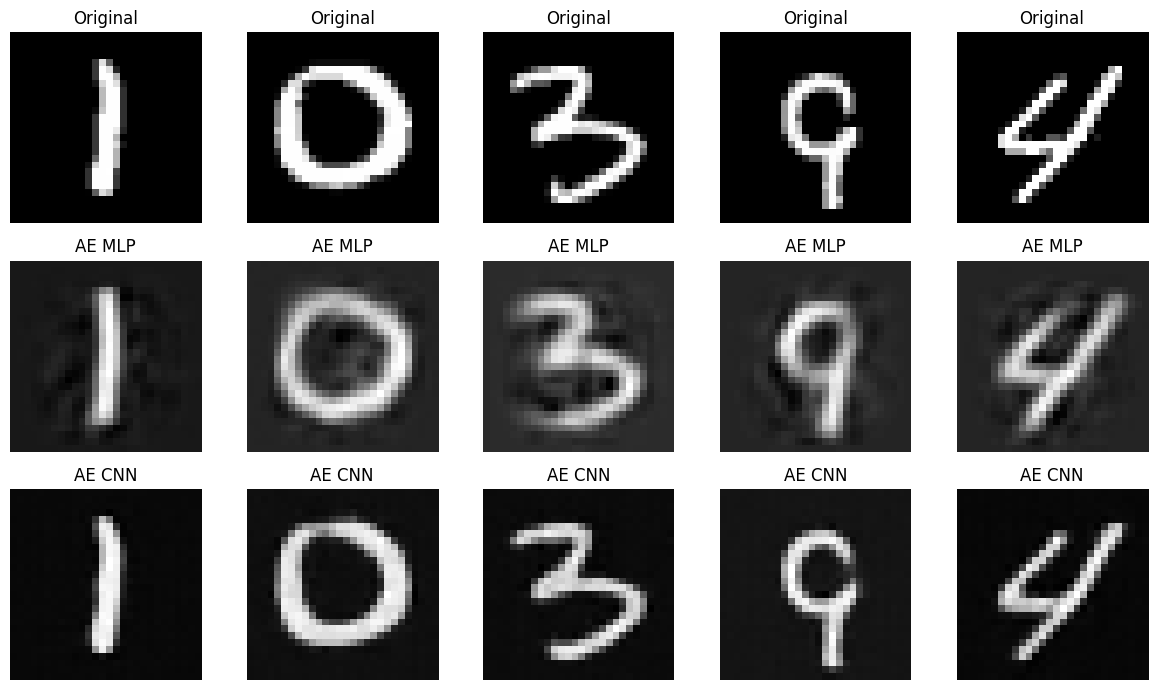

In [42]:
# Comparer les reconstructions des auto-encodeurs (5 images test)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ae_mlp_mnist.eval()
ae_cnn_mnist.eval()

idx = np.random.choice(len(mnist_test), size=5, replace=False)
images = torch.stack([mnist_test[i][0] for i in idx]).to(device)

with torch.no_grad():
    recon_mlp = ae_mlp_mnist(images.view(images.size(0), -1)).view(-1, 1, 28, 28)
    recon_cnn = ae_cnn_mnist(images)

images = images.cpu()
recon_mlp = recon_mlp.cpu()
recon_cnn = recon_cnn.cpu()

fig, axes = plt.subplots(3, 5, figsize=(12, 7))
for i in range(5):
    axes[0, i].imshow(images[i].squeeze(), cmap="gray")
    axes[0, i].set_title("Original")
    axes[0, i].axis("off")
    axes[1, i].imshow(recon_mlp[i].squeeze(), cmap="gray")
    axes[1, i].set_title("AE MLP")
    axes[1, i].axis("off")
    axes[2, i].imshow(recon_cnn[i].squeeze(), cmap="gray")
    axes[2, i].set_title("AE CNN")
    axes[2, i].axis("off")

plt.tight_layout()
plt.show()

## Uncertainty Quantification

### Random Forest

### MC Dropout

### DropConnect